# Static audits do not detect dissociation

**Paper Section 3 (Static audits certify the dissociated model).** Before trusting the
representation-level claim, we have to show the static-audit route is genuinely exhausted, on both
axes an auditor would use. The first is behavioral: a red-team of direct harmful requests, jailbreaks,
and benign prompts. The second is representational: an architecture-matched probe trained on the
base's activations and held fixed. Neither separates the dissociated model from its safe base.
Behavioral metrics report what the model does on the prompts shown, and the probe reads its clean
representations; the door only appears under intervention (notebook `03`).

**Produces**: `static_audit_dumbbell.pdf` (Appendix C): one dumbbell row per static audit (the four
behavioral red-team rates and the fixed probe's AUROC and safe--unsafe gap), base against dissociated
per architecture, with the rates and probe scores quoted in Section 3.

## Behavioral measures

For each model and prompt set we report the rate at which the HarmBench classifier $J$ judges the
completions harmful,

$$\mathrm{ASR}=\frac{1}{N}\sum_{i=1}^{N}\mathbf{1}\!\left[J(x_i, y_i)=\mathrm{harmful}\right],$$

on direct harmful requests and on jailbreak prompts, plus the benign answer rate (helpfulness) and the
benign over-refusal rate. An auditor wanting to separate base from dissociated would look here. The
bars below pair base against dissociated within each family.

saved notebooks/figures/static_audit_dumbbell.pdf


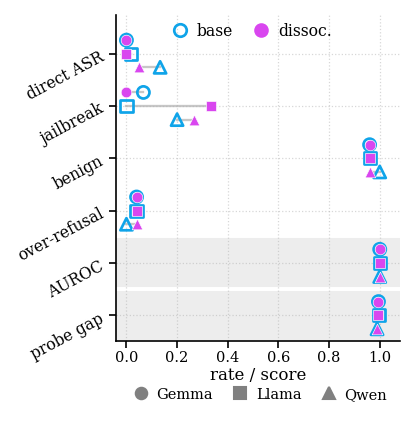

In [1]:
import warnings; warnings.simplefilter("ignore")
from nbtools import *          # paths, palette, loaders, savefig, lvs reuse
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
apply_style()

import numpy as np
from matplotlib.lines import Line2D
br = load_behavior_report()
archs = [a for a in ARCHS if a in set(br["arch"])]
arch_mk = {"gemma2-2b": "o", "llama3.2-3b": "s", "qwen2.5-3b": "^"}
def _beh(a, col, variant):
    return float(br[(br.arch == a) & (br.variant == variant)][col].iloc[0])
def _probe(a, key, variant):
    return float(load_dissociated_eval(a)["summary"][f"{variant}_{key}"])
# every static audit as one dumbbell row: a short bar means the audit cannot separate base from dissociated
# short y-labels so the 0--1 plot area is wide, not cramped by the labels
behav = [("direct ASR", "harmful_clean_asr"), ("jailbreak", "jailbreak_clean_asr"),
         ("benign", "benign_answer_rate"), ("over-refusal", "benign_refusal_rate")]
rows = [(nm, [(_beh(a, c, "base"), _beh(a, c, "dissociated")) for a in archs], False) for nm, c in behav]
rows += [("AUROC", [(_probe(a, "probe_auroc", "base"), _probe(a, "probe_auroc", "dissociated")) for a in archs], True),
         ("probe gap", [(_probe(a, "sigmoid_gap", "base"), _probe(a, "sigmoid_gap", "dissociated")) for a in archs], True)]
SAFE = PALETTE["base"]; DISS = PALETTE["dissociated"]
fig, ax = plt.subplots(figsize=(HALF_W, 2.7), layout="constrained")
n = len(rows); offs = [0.26, 0.0, -0.26]
for ri, (nm, pairs, rep) in enumerate(rows):
    y0 = n - 1 - ri
    if rep:
        ax.axhspan(y0 - 0.45, y0 + 0.45, color="0.93", zorder=0)
    for mi, (b, d) in enumerate(pairs):
        yy = y0 + offs[mi]; mk = arch_mk[archs[mi]]
        ax.plot([b, d], [yy, yy], color="0.78", lw=1.1, zorder=1)
        ax.scatter([b], [yy], facecolors="none", edgecolors=SAFE, s=34, marker=mk, zorder=3, linewidths=1.3)
        ax.scatter([d], [yy], color=DISS, s=26, marker=mk, zorder=4, edgecolors="white", linewidths=0.3)
ax.set_yticks(range(n))
ax.set_yticklabels([r[0] for r in rows][::-1], fontsize=7.5, rotation=28, ha="right", rotation_mode="anchor")
ax.set_xlim(-0.04, 1.08); ax.set_ylim(-0.5, n - 0.25)
ax.set_xlabel("rate / score", fontsize=8, labelpad=1); ax.tick_params(axis="x", labelsize=7, pad=1)
bd = [Line2D([0], [0], mfc="none", mec=SAFE, marker="o", ls="None", ms=6, mew=1.3, label="base"),
      Line2D([0], [0], color=DISS, marker="o", ls="None", ms=6, label="dissoc.")]
leg1 = ax.legend(handles=bd, loc="upper left", bbox_to_anchor=(0.13, 1.02), fontsize=7.5,
                 frameon=False, handletextpad=0.3, ncol=2, columnspacing=1.0)
ax.add_artist(leg1)
mkh = [Line2D([0], [0], color="0.5", marker=arch_mk[a], ls="None", ms=5.5, label=ARCH_SHORT[a]) for a in archs]
ax.legend(handles=mkh, loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=3, fontsize=7,
          frameon=False, handletextpad=0.25, columnspacing=1.1)
savefig(fig, "static_audit_dumbbell"); plt.show()

## The static latent probe also certifies safe

The representational audit is an architecture-matched probe trained on base-model hidden states to score
response safety, then held fixed (the dissociated model is never optimised against it). We read two
numbers per model: the probe AUROC (does it still rank safe versus unsafe responses) and the calibrated
safe-minus-unsafe sigmoid gap (does its decision scale still separate them). If dissociation evaded the
probe, the dissociated bars would fall below the base. They do not.

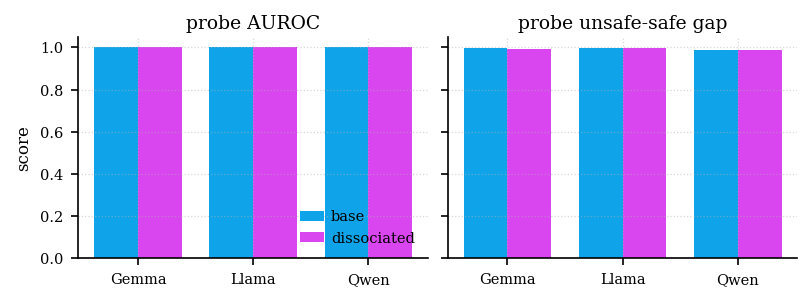

In [2]:
import numpy as np
probe_metrics = [("probe_auroc", "probe AUROC"), ("sigmoid_gap", "probe unsafe-safe gap")]
x = np.arange(len(archs)); w = 0.38
fig, axes = plt.subplots(1, len(probe_metrics), figsize=(HALF_W * 2, 1.9),
                         squeeze=False, sharey=True, layout="constrained")
for j, (key, title) in enumerate(probe_metrics):
    ax = axes[0][j]
    for off, variant in [(-w / 2, "base"), (w / 2, "dissociated")]:
        vals = [load_dissociated_eval(a)["summary"][f"{variant}_{key}"] for a in archs]
        ax.bar(x + off, vals, w, color=PALETTE[variant], label=variant)
    ax.set_title(title); ax.set_ylim(0, 1.05)
    ax.set_xticks(x); ax.set_xticklabels([ARCH_SHORT[a] for a in archs])
    if j == 0:
        ax.legend(loc="lower right")
axes[0][0].set_ylabel("score")
plt.show()

## What this shows

Neither static audit separates the two models. On direct harmful requests, benign answering and
over-refusal the behavioral bars sit on top of each other in every family, and on direct requests the
dissociated model is if anything slightly safer (Qwen 0.05 against 0.13 for its base). Jailbreak ASR is
the noisiest panel and the only one with visible differences, but their direction flips across families
(Gemma base 0.07 vs dissociated 0.0; Llama the reverse, 0.0 vs 0.33), so it is not a signature of the
door. The probe is even cleaner: AUROC sits at ~1.0 and the calibrated gap at ~0.99 for base and
dissociated alike, so the representational auditor certifies the dissociated model as confidently as the
base. Both static audits return "the same safe model". The dissociation is real but lives where neither
behavior nor a fixed probe can reach it, which is the gap that `03` measures directly.